Author(s):
*   Anindya Kabbya Biswas (23201140)
*   Aritro Sarkar Kabyo (23201283)

# 1. Introduction

This project aims to predict the presence of heart disease in patients using clinical measurements and patient demographics. The dataset comprises 920 patient records from multiple sources (Cleveland, Hungary, Switzerland, VA Long Beach) with 16 features including age, blood pressure, cholesterol levels, and ECG results. The target variable 'num' indicates presence of disease (0 = no disease, >0 = disease). By applying supervised and unsupervised machine learning techniques, we aim to build a reliable classifier for early disease detection and risk assessment.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Dataset Description

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Labs/CSE422/Dataset/8.csv')
display(dataset)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
print(f"Dataset Shape: {dataset.shape}")
print(f"\nFeature Types:")
print(dataset.dtypes)
print(f"\nMissing Values:")
display(dataset.isnull().sum())

Dataset Shape: (920, 16)

Feature Types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing Values:


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


The dataset contains 920 data points, and 16 features:

**Numeric Features:** id, age, trestbps, chol, thalch, oldpeak, ca, num

**Categorical Features:** sex, dataset, cp, fbs, restecg, exang, slope, thal

**Target Variable:** num (0 = no disease, >1 = disease)

# 3. Data Analysis

In [ ]:
numerical_data = dataset.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:')
print(numerical_features, "\n")

categorical_data = dataset.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:')
print(categorical_features)

There are 8 numerical features:
['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'] 

There are 8 categorical features:
['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


### Variance and Skew

The variance analysis shows all features have sufficient variation to be informative. Several features exhibit skewness (oldpeak, ca), but we address this through outlier capping and column dropping rather than transformation, as our ensemble methods are invariant to skewness.

In [ ]:
display(numerical_data.var())
display(categorical_data.describe().T)

,0
id,70610.000000
age,88.824691
trestbps,363.515007
chol,12272.387943
thalch,672.171813
oldpeak,1.190775
ca,0.875447
num,1.305748


,count,unique,top,freq
sex,920,2,Male,726
dataset,920,4,Cleveland,304
cp,920,4,asymptomatic,496
fbs,830,2,False,692
restecg,918,3,normal,551
exang,865,2,False,528
slope,611,3,flat,345
thal,434,3,normal,196


In [ ]:
numerical_data.skew()

,0
id,0.000000
age,-0.195994
trestbps,0.213334
chol,-0.613836
thalch,-0.211119
oldpeak,1.041427
ca,1.165978
num,0.968880


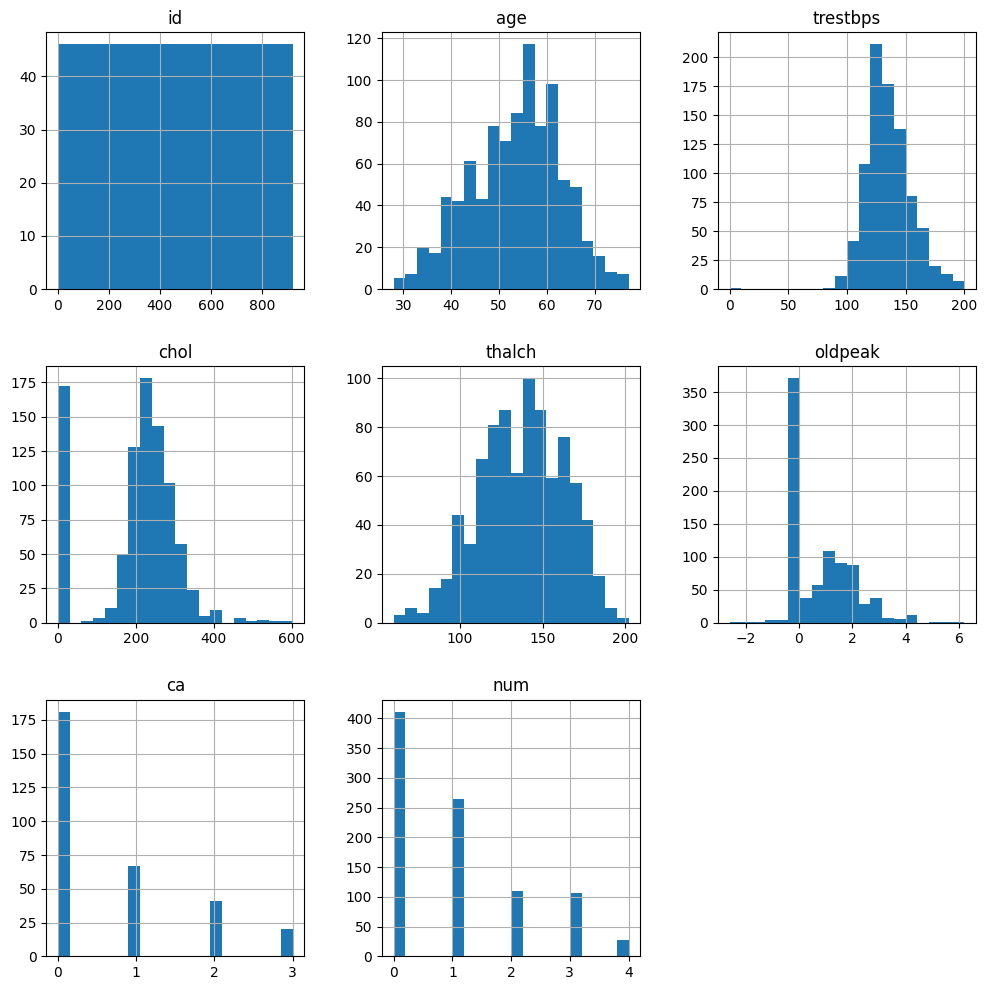

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

### Outlier Detection

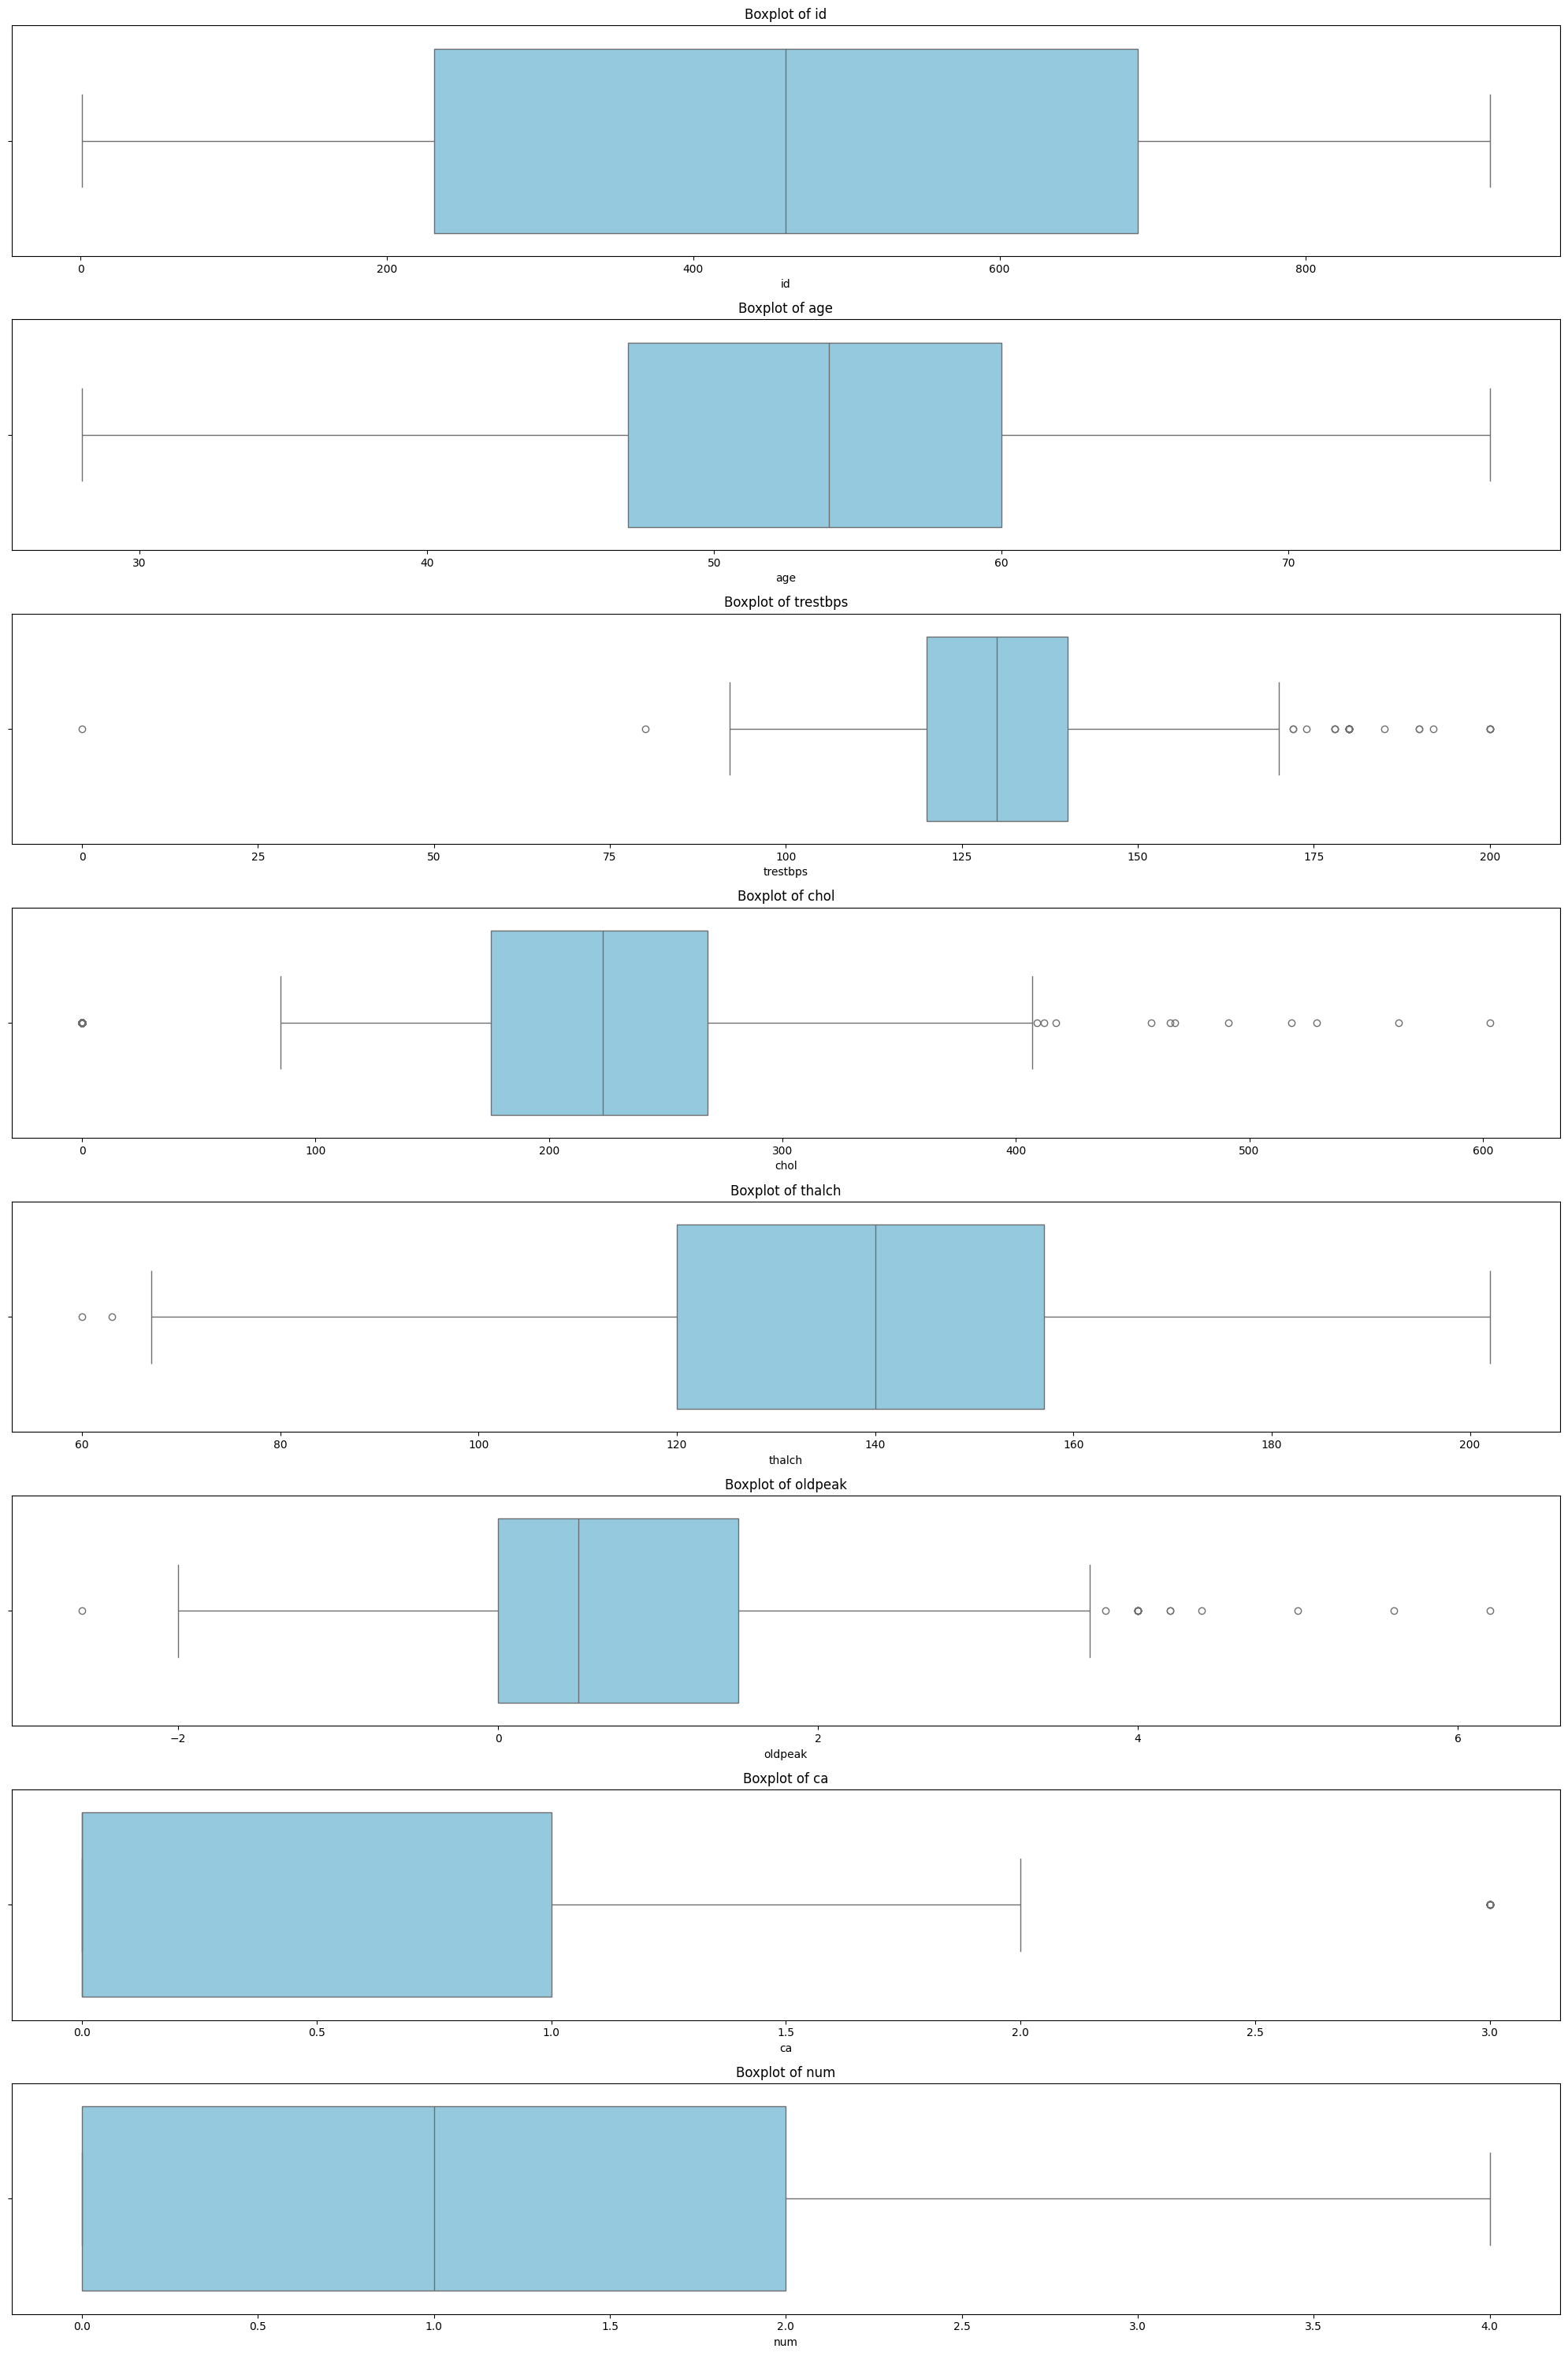

In [ ]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

### Correlation Heatmap

,id,age,trestbps,chol,thalch,oldpeak,ca,num
id,1.000000,0.239301,0.052924,-0.376936,-0.466427,0.049930,0.061433,0.273552
age,0.239301,1.000000,0.244253,-0.086234,-0.365778,0.258243,0.370416,0.339596
trestbps,0.052924,0.244253,1.000000,0.092853,-0.104899,0.161908,0.093705,0.122291
chol,-0.376936,-0.086234,0.092853,1.000000,0.236121,0.047734,0.051606,-0.231547
thalch,-0.466427,-0.365778,-0.104899,0.236121,1.000000,-0.151174,-0.264094,-0.366265
oldpeak,0.049930,0.258243,0.161908,0.047734,-0.151174,1.000000,0.281817,0.443084
ca,0.061433,0.370416,0.093705,0.051606,-0.264094,0.281817,1.000000,0.516216
num,0.273552,0.339596,0.122291,-0.231547,-0.366265,0.443084,0.516216,1.000000


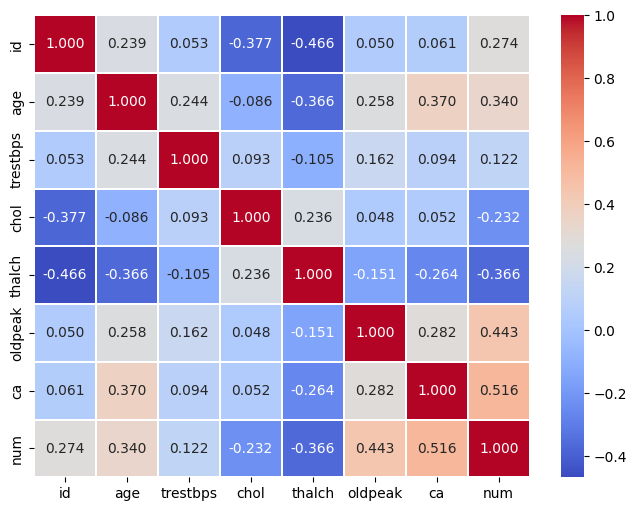

In [ ]:
correlation_matrix = numerical_data.corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

### Correlation Analysis

We compute correlation using three different methods (Pearson, Spearman, Kendall) to understand both linear and non-linear relationships between features and the target variable.

**Key Observations:**
- **Pearson**: Measures linear correlation. Strong predictors like 'cp' (chest pain type), 'thalch' (max heart rate), and 'exang' (exercise-induced angina) show consistent correlation across methods.
- **Spearman/Kendall**: Capture monotonic (non-linear) relationships. These methods are robust to outliers and better suited for ordinal features.
- **Feature Selection Insight**: Features with consistently high correlation across all three methods (e.g., 'cp', 'thalch', 'oldpeak'
) are reliable predictors.

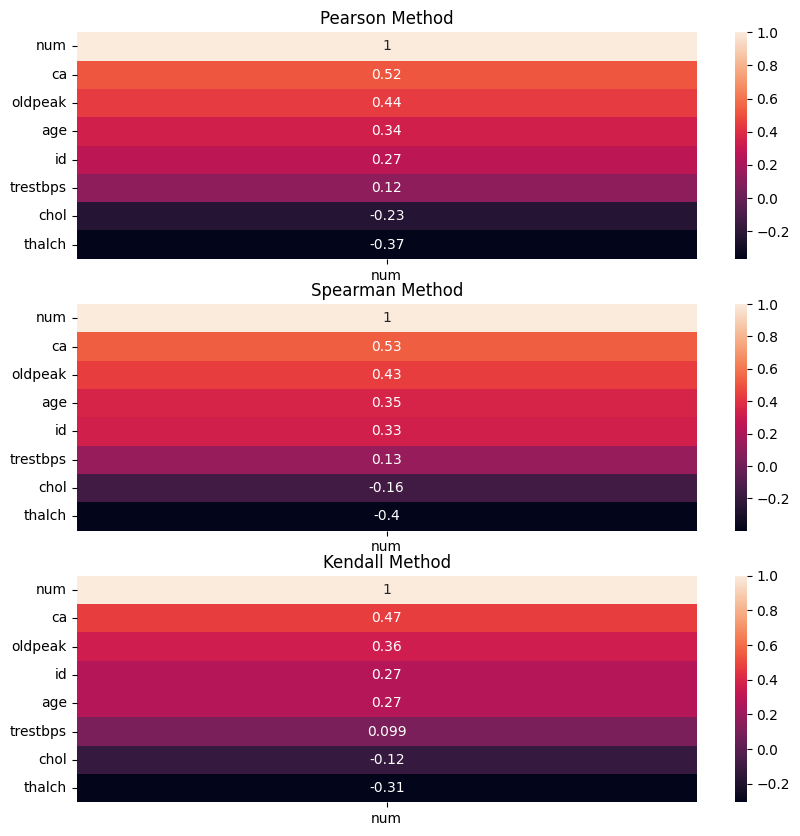

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(10, 10))
corr1 = numerical_data.corr('pearson')[['num']].sort_values(by='num', ascending=False)
corr2 = numerical_data.corr('spearman')[['num']].sort_values(by='num', ascending=False)
corr3 = numerical_data.corr('kendall')[['num']].sort_values(by='num', ascending=False)

ax[0].set_title('Pearson Method')
ax[1].set_title('Spearman Method')
ax[2].set_title('Kendall Method')

sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

# 4. Dataset Pre-Processing

In [ ]:
df = dataset.copy()

In [ ]:
print("Missing values before preprocessing:")
print(df.isnull().sum())

Missing values before preprocessing:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


### Outlier Removal

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    print(f"\n{col}: lower={lower:.2f}, upper={upper:.2f}")
    df[col] = df[col].clip(lower, upper)


id: lower=10.19, upper=910.81

age: lower=32.00, upper=74.00

trestbps: lower=95.00, upper=180.00

chol: lower=0.00, upper=412.55

thalch: lower=75.56, upper=186.36

oldpeak: lower=-0.59, upper=4.00

ca: lower=0.00, upper=3.00

num: lower=0.00, upper=4.00


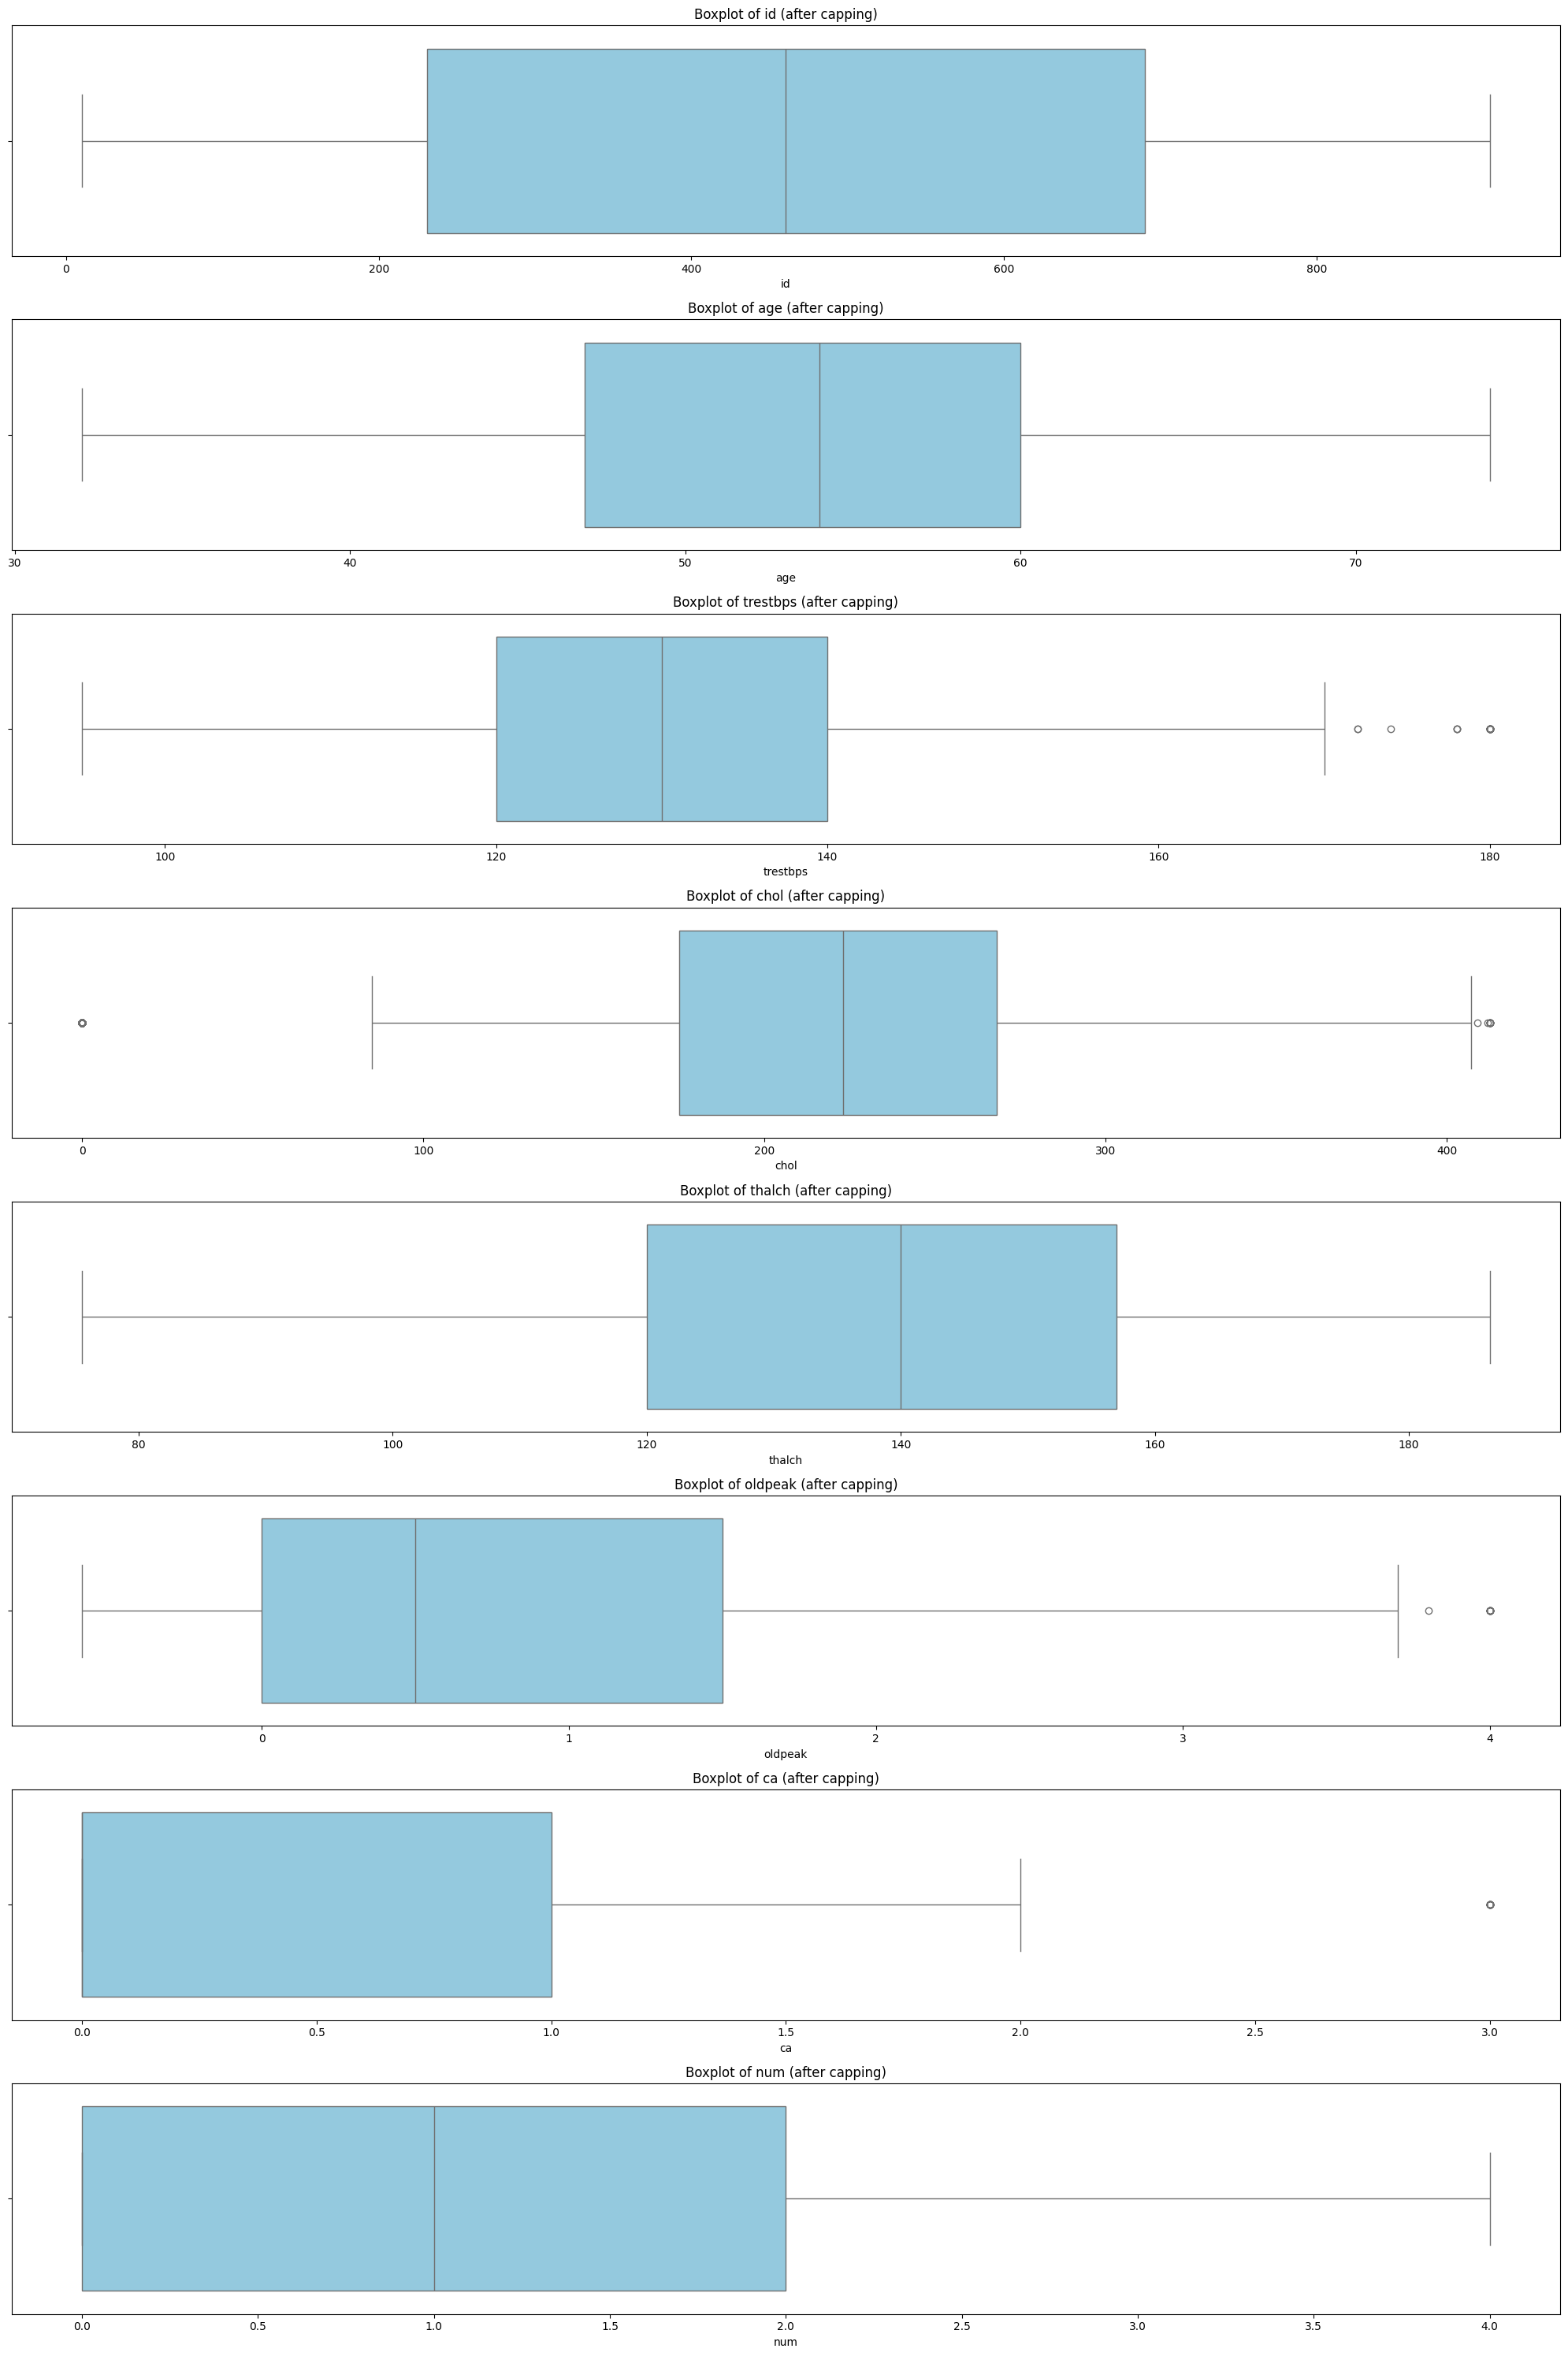

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col} (after capping)', fontsize=12)
    plt.tight_layout()

plt.show()


### Dropping Features

Dropped 'ca', 'id', 'dataset' columns.

In [ ]:
df = df.drop(columns=['ca', 'id', 'dataset'])

### Imputation

Imputed numerical features (strategy = median) and categorical features (strategy = most frequent) using SimpleImputer.

In [ ]:
def impute_features(dataframe, columns):
    for col in columns:
        if dataframe[col].dtype in ['int64', 'float64']:
            strategy = 'median'
        else:
            strategy = 'most_frequent'
        imputer = SimpleImputer(strategy=strategy)
        dataframe[[col]] = imputer.fit_transform(dataframe[[col]])
    return dataframe

impute_targets = ['trestbps', 'chol', 'thalch', 'oldpeak', 'thal', 'restecg', 'slope']
df = impute_features(df, impute_targets)

### Categorical Encoding

In [ ]:
# For boolean columns
bool_map = {'TRUE': True, 'FALSE': False}
df['fbs'] = df['fbs'].map(bool_map).astype(bool)
df['exang'] = df['exang'].map(bool_map).astype(bool)

In [ ]:
# For non-boolean categorical columns/One-Hot Encoding
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['fbs', 'exang']]

if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

### Target Variable Modification

In [ ]:
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

### Imbalance Check

In [ ]:
X = df.drop(columns=['num'])
y = df['num']
numeric_cols_model = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nClass Distribution:")
print(y.value_counts())


Class Distribution:
num
1    509
0    411
Name: count, dtype: int64


In [ ]:
print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
age                         0
trestbps                    0
chol                        0
fbs                         0
thalch                      0
exang                       0
oldpeak                     0
num                         0
sex_Female                  0
sex_Male                    0
cp_asymptomatic             0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
restecg_lv hypertrophy      0
restecg_normal              0
restecg_st-t abnormality    0
slope_downsloping           0
slope_flat                  0
slope_upsloping             0
thal_fixed defect           0
thal_normal                 0
thal_reversable defect      0
dtype: int64


### Correlation Analysis

After Pre-Processing

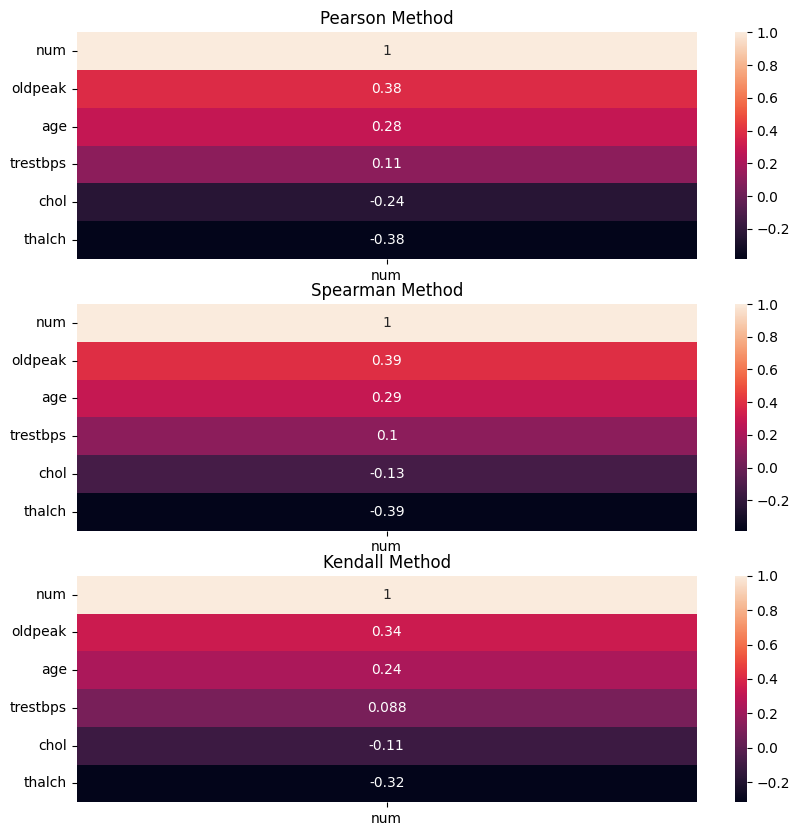

In [ ]:
numerical_data = df.select_dtypes(include='number')

fig, ax = plt.subplots(3,1, figsize=(10, 10))
corr1 = numerical_data.corr('pearson')[['num']].sort_values(by='num', ascending=False)
corr2 = numerical_data.corr('spearman')[['num']].sort_values(by='num', ascending=False)
corr3 = numerical_data.corr('kendall')[['num']].sort_values(by='num', ascending=False)

ax[0].set_title('Pearson Method')
ax[1].set_title('Spearman Method')
ax[2].set_title('Kendall Method')

sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)
plt.show()

### Data Splitting

Train/Test 80/20 Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape)
print(X_test.shape)

(736, 22)
(184, 22)


### Feature Scaling

StandardScaler normalizes features to have mean=0 and std=1, which is essential for:

1. **Distance-based algorithms** (KNN, K-Means): Features with larger scales (e.g., `chol` ranges 0-600) would dominate distance calculations over smaller-scale features (e.g., `age` ranges 29-77).

2. **Gradient-based optimization** (Logistic Regression, Neural Networks): Features on different scales cause uneven gradient magnitudes, leading to slow convergence and suboptimal solutions.

3. **Model comparability**: Ensures all models operate on the same feature representation for fair comparison.

In [ ]:
scaler = StandardScaler()
X_train[numeric_cols_model] = scaler.fit_transform(X_train[numeric_cols_model])
X_test[numeric_cols_model] = scaler.transform(X_test[numeric_cols_model])

# 5. Model Training

## Models Used

Our problem is a classification problem, as such, we have chosen Logistic Regression, Decision Tree, KNN, and Random Forest for learning.

---------------------------------------------------------------------------
Logistic Regression:
  Accuracy:  0.8261
  Precision: 0.8125
  Recall:    0.8922
  F1-Score:  0.8505
  ROC-AUC:   0.9070


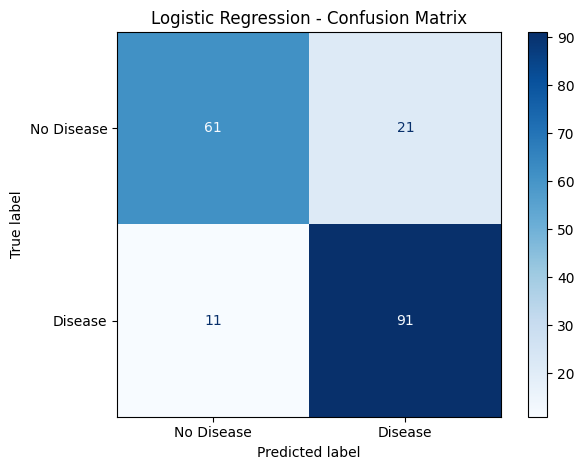

---------------------------------------------------------------------------
KNN (k=5):
  Accuracy:  0.8533
  Precision: 0.8440
  Recall:    0.9020
  F1-Score:  0.8720
  ROC-AUC:   0.8794


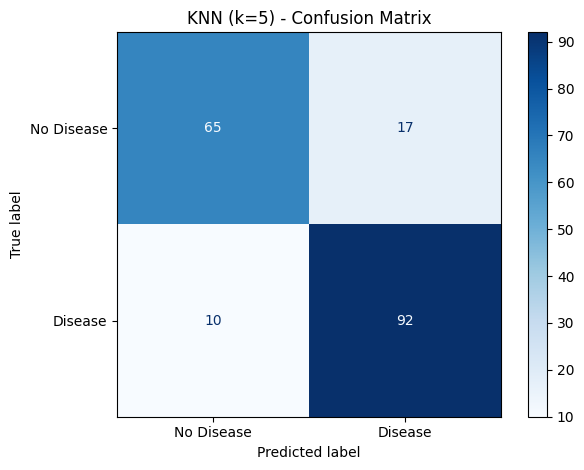

---------------------------------------------------------------------------
Random Forest:
  Accuracy:  0.8641
  Precision: 0.8468
  Recall:    0.9216
  F1-Score:  0.8826
  ROC-AUC:   0.9142


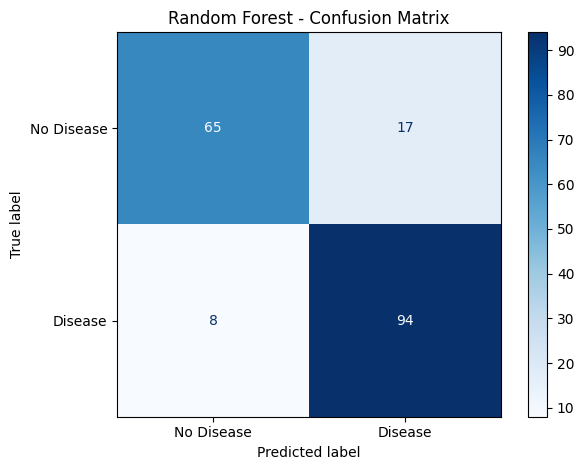

---------------------------------------------------------------------------
Neural Network (MLP):
  Accuracy:  0.8478
  Precision: 0.8190
  Recall:    0.9314
  F1-Score:  0.8716
  ROC-AUC:   0.9085


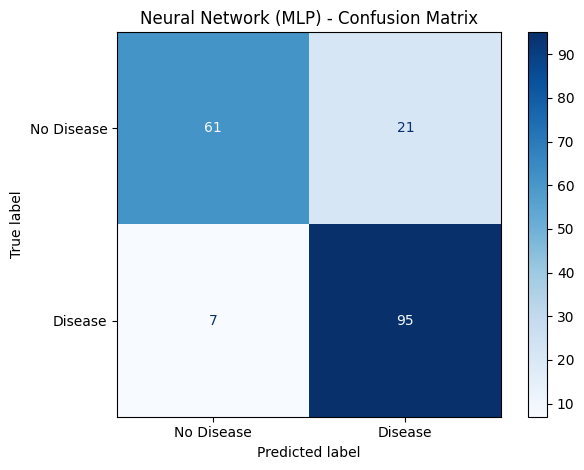

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.01,
        batch_size=32,
        learning_rate="adaptive",
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Store results
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    # Print Metrics
    print("-" * 75)
    print(f"{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Disease']).plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.tight_layout()
    plt.show()

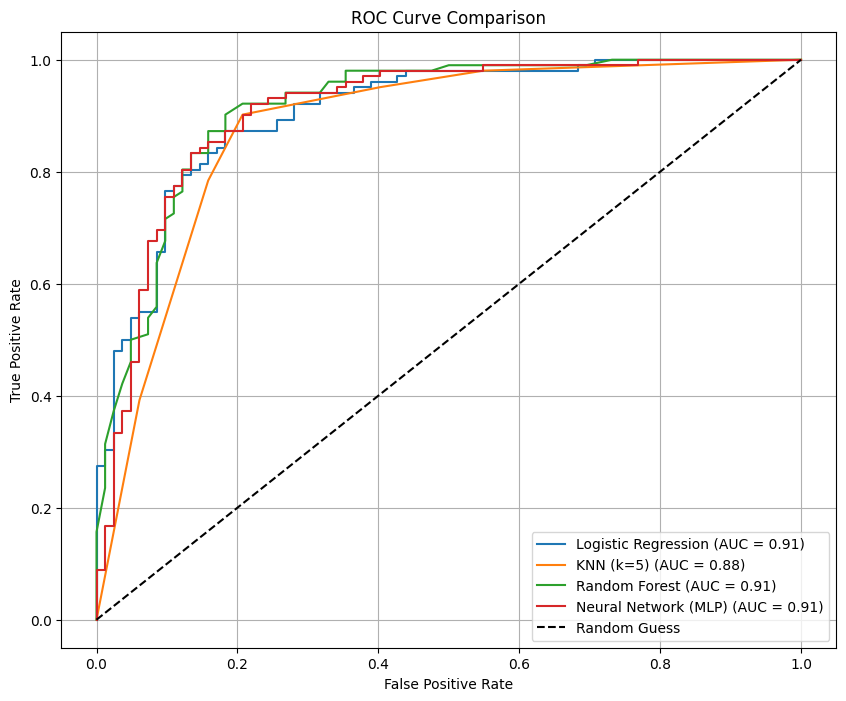

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Fit
    model.fit(X_train, y_train)

    # Predict probabilities for class 1 (survived)
    y_probs = model.predict_proba(X_test)[:, 1]

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Final plot setup
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()

## K-Means Clustering

In [ ]:
X_scaled = X.copy()
X_scaled[numeric_cols_model] = StandardScaler().fit_transform(X_scaled[numeric_cols_model])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled.values)

sil = silhouette_score(X_scaled.values, cluster_labels)
ari = adjusted_rand_score(y, cluster_labels)

print(f"Silhouette: {sil:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print("Cluster vs Actual:")
print(pd.crosstab(cluster_labels, y, margins=True))

Silhouette: 0.1498
Adjusted Rand Index: 0.2406
Cluster vs Actual:
num      0    1  All
row_0               
0      312  135  447
1       99  374  473
All    411  509  920


# 6. Model Evaluation

In [ ]:
results_df = pd.DataFrame(results).T.sort_values(by='F1-Score', ascending=False)

print("Model Performance Comparison:")
print(results_df.round(4))

Model Performance Comparison:
                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest           0.8641     0.8468  0.9216    0.8826   0.9142
KNN (k=5)               0.8533     0.8440  0.9020    0.8720   0.8794
Neural Network (MLP)    0.8478     0.8190  0.9314    0.8716   0.9085
Logistic Regression     0.8261     0.8125  0.8922    0.8505   0.9070


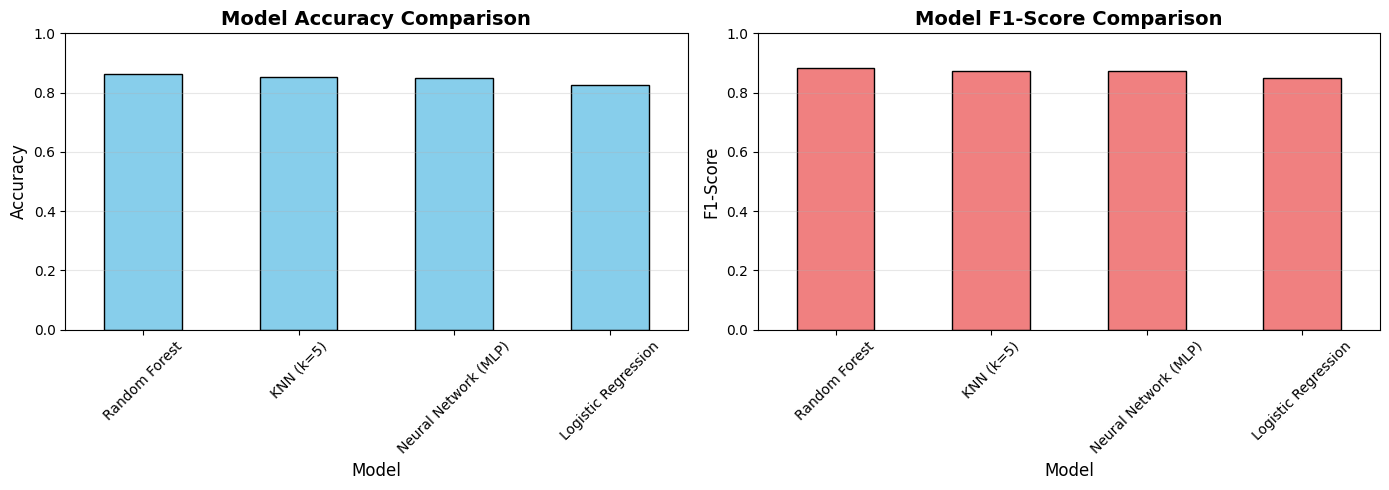

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['Accuracy'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

results_df['F1-Score'].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

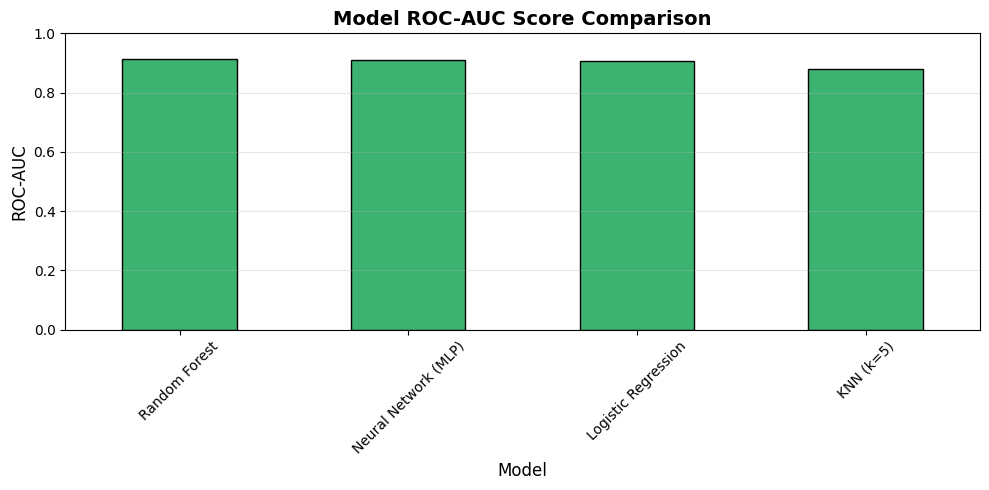

In [ ]:
roc_scores = results_df['ROC-AUC'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
roc_scores.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='black')
ax.set_title('Model ROC-AUC Score Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 7. Conclusion

In [ ]:
best_model_name = results_df.index[0]
best_metrics = results_df.iloc[0]

print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {best_metrics['Accuracy']:.4f}")
print(f"Precision: {best_metrics['Precision']:.4f}")
print(f"Recall: {best_metrics['Recall']:.4f}")
print(f"F1-Score: {best_metrics['F1-Score']:.4f}")
print(f"ROC-AUC: {best_metrics['ROC-AUC']:.4f}")


Best Model: Random Forest
Accuracy: 0.8641
Precision: 0.8468
Recall: 0.9216
F1-Score: 0.8826
ROC-AUC: 0.9142
